# **Datasets with PyTorch**
In this section we'll show how to:
* load data from outside files
* build random batches using PyTorch's <a href='https://pytorch.org/docs/stable/data.html'><strong><tt>data</tt></strong></a> utilities<br>



In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris


## **Loading data from files**
We've seen how to load NumPy arrays into PyTorch, and anyone familiar with <tt>pandas.read_csv()</tt> can use it to prepare data before forming tensors. Here we'll load the <a href='https://en.wikipedia.org/wiki/Iris_flower_data_set'>iris flower dataset</a> saved as a .csv file.

In [2]:
iris = load_iris()
X = iris.data    # 4 features: sepal length, sepal width, petal length, petal width
y = iris.target

In [5]:
df = pd.read_csv('iris.csv')
df.head()

,150,4,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df.shape

(150, 5)

## **Plot the data**

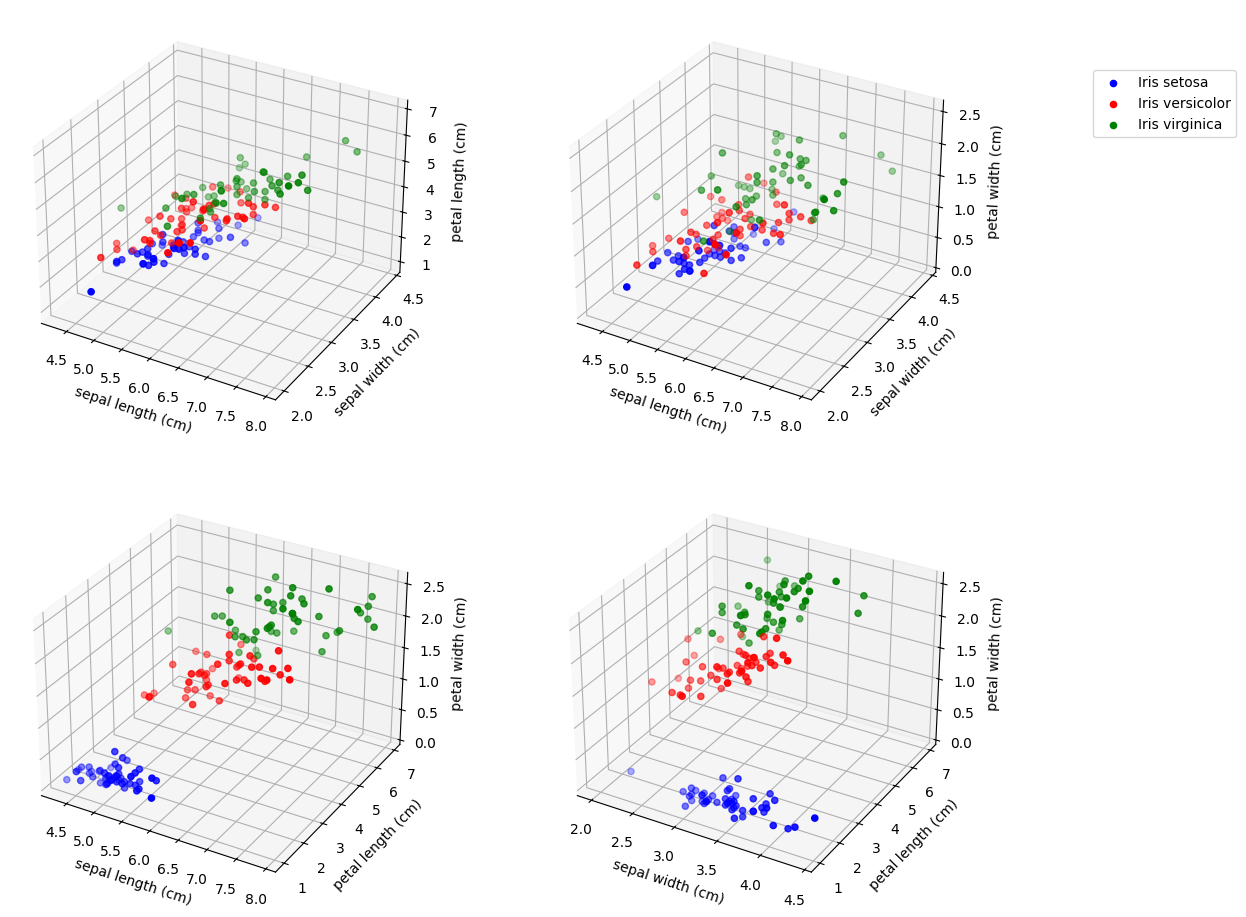

In [ ]:
import matplotlib.pyplot as plt

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

# 3. Add the 3D projection using subplot_kw and set figsize
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), subplot_kw={'projection': '3d'})
fig.tight_layout(pad=4.0)

# 4. Update plots to include combinations of 3 features (x, y, z)
plots = [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]
colors = ['b', 'r', 'g']

# FIXED: 0 = Setosa, 1 = Versicolor, 2 = Virginica
labels = ['Iris setosa', 'Iris versicolor', 'Iris virginica']

for i, ax in enumerate(axes.flat):
    for j in range(3):
        # Identify the columns for all three dimensions
        col_x = df.columns[plots[i][0]]
        col_y = df.columns[plots[i][1]]
        col_z = df.columns[plots[i][2]]

        # Filter the data points
        # (Renamed to x_vals, y_vals, z_vals to avoid confusion with the target variable 'y')
        x_vals = df[df['target'] == j][col_x]
        y_vals = df[df['target'] == j][col_y]
        z_vals = df[df['target'] == j][col_z]

        # Plot using the 3D scatter method
        ax.scatter(x_vals, y_vals, z_vals, color=colors[j])

        # Set labels for all three axes
        ax.set_xlabel(col_x)
        ax.set_ylabel(col_y)
        ax.set_zlabel(col_z)

fig.legend(labels=labels, loc='center left', bbox_to_anchor=(1.0, 0.85))
plt.show()

The Iris dataset is considered the "Hello World" of data science and machine learning.

It contains 150 samples of Iris flowers used to practice classification and data visualization.

- Features (Inputs): Four measurements per flower (sepal length, sepal width, petal length, petal width).

- Target Classes (Outputs): Three species, with 50 samples each (Iris setosa, Iris versicolor, and Iris virginica).

### **Using Scikit-learn for building train/test split tensors**
Before introducing PyTorch's Dataset and DataLoader classes, we'll take a quick look at the alternative.

PyTorch models require inputs to be tensors, not NumPy arrays.

`FloatTensor()` specifically converts the data into 32-bit floats, which is the standard, expected data type for calculating weights and gradients in neural networks.

Alternatives are:


- `torch.tensor(data, dtype=torch.float32)`: This is the modern, standard way to create a tensor. It is highly recommended because it forces you to explicitly state the data type (dtype), which makes your code cleaner and prevents unexpected type-casting bugs.

- `torch.as_tensor(data, dtype=torch.float32)`: This is the most efficient option when working with NumPy arrays (like your train_X variable). Unlike torch.tensor() which always creates a brand new copy of your data, as_tensor will try to share memory with the original NumPy array, saving time and memory space.

- `torch.from_numpy(data).float()`: This specifically tells PyTorch to bridge the NumPy array into a tensor (also sharing memory), and then explicitly casts it to a 32-bit float.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('target',axis=1).values
y = df['target'].values

train_X, test_X, train_y, test_y = train_test_split(X,y,test_size=0.2,random_state=33)

X_train = torch.FloatTensor(train_X)
X_test = torch.FloatTensor(test_X)
y_train = torch.LongTensor(train_y).reshape(-1, 1)
y_test = torch.LongTensor(test_y).reshape(-1, 1)

The target does not need to be float so we use `LongTensor`.

`reshape(-1, 1)`: Scikit-learn outputs your target y as a flat 1D list (e.g., shape [120]). However, PyTorch loss functions usually require the target variable to be a 2D column vector (shape [120, 1]) so it perfectly matches the shape of the model's output predictions. The -1 keeps all your rows intact, and the 1 forces the data into a single column.

In [ ]:
print(f'Training size: {len(y_train)}')
labels, counts = y_train.unique(return_counts=True)
print(f'Labels: {labels}\nCounts: {counts}')

Training size: 120
Labels: tensor([0, 1, 2])
Counts: tensor([42, 42, 36])


In [ ]:
X_train.size()

torch.Size([120, 4])

<div class="alert alert-info"><strong>NOTE: </strong>It's up to us to remember which columns correspond to which features.</div>

In [ ]:
y_train.size()

torch.Size([120, 1])

Alternatively we can use `shape`. They both return the dimensions of your tensor.

The distinction is purely in how they are implemented in PyTorch's code:

`.size()` is a method: It is a function built directly into PyTorch tensors. Because it's a function, you can pass a specific dimension directly into it, like X_train.size(0) to get just the number of rows.

`.shape` is an attribute: PyTorch added this specifically to mirror NumPy's syntax, making it easier for people coming from Scikit-Learn or Pandas. Because it's an attribute, you access specific dimensions using brackets, like X_train.shape[0].

In [ ]:
X_train.shape

torch.Size([120, 4])

## **Using PyTorch's Dataset and DataLoader classes for building tensors**
While converting data directly into tensors works for small datasets like Iris, the standard best practice in PyTorch is to wrap those tensors in <a href='https://pytorch.org/docs/stable/data.html'><strong><tt>Dataset</tt></strong></a> and <a href='https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader'><strong><tt>DataLoader</strong></tt></a> classes. These tools don't just hold your data; they automatically handle shuffling, splitting data into mini-batches, and efficiently feeding it to your model during training.



Usually, to set up a Dataset specific to our investigation we would define our own custom class that inherits from <tt>torch.utils.data.Dataset</tt> (we'll do this in the CNN section). For now, we can use the built-in <a href='https://pytorch.org/docs/stable/data.html#torch.utils.data.TensorDataset'><strong><tt>TensorDataset</tt></strong></a> class.
<br>

#### **What are Batches and Epochs?**

**Batch:** A subset of data samples processed together by the model before it pauses to update its learning.

**Epoch:** One complete pass through the entire dataset, meaning the model has seen every single piece of training data exactly once.

<br>

#### **Why do we use Batch?**

- Memory: It breaks massive datasets into small chunks so your computer's memory doesn't overload and crash.

- Speed: It allows computer hardware to calculate multiple data points simultaneously, which is much faster than processing them one by one.

- Learning: It lets the neural network update its knowledge frequently (after every batch) instead of waiting until the very end of the dataset.


<br>

#### **Variations:**

**Full Batch (Batch Gradient Descent):**
A Full Batch means the neural network looks at the entire dataset all at once before it makes a single update to its internal weights (what it has learned).


**Mini-Batch (Mini-Batch Gradient Descent):**
A Mini-Batch means taking that massive dataset and chopping it up into smaller, bite-sized chunks (usually 16, 32, 64, or 128 samples). The network looks at one mini-batch, makes an update to its weights, and then moves on to the next mini-batch.

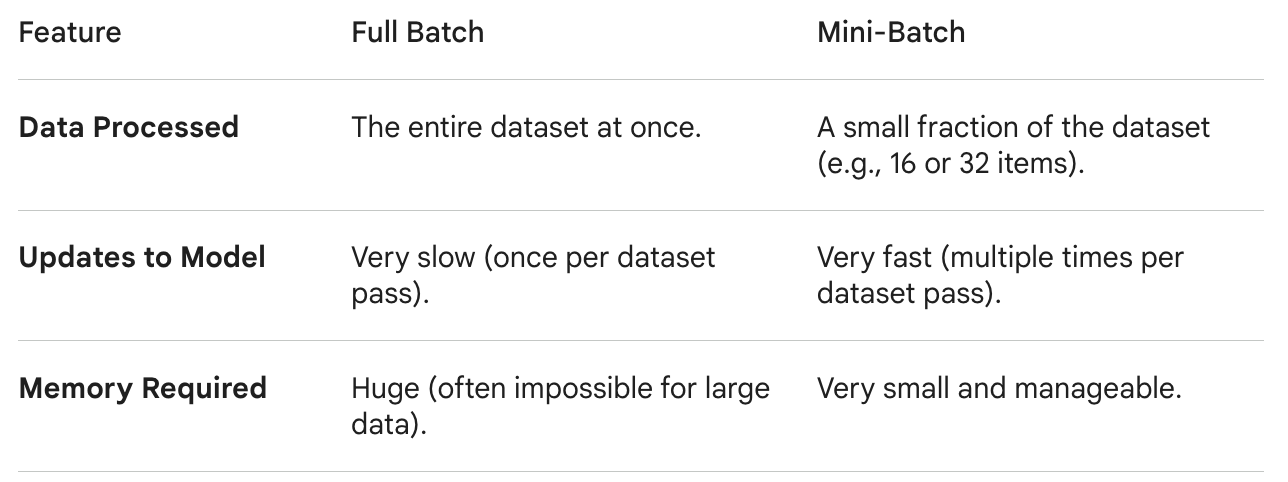

#### **Epoch vs Full Batch**

While they often contain the exact same amount of data, they measure two completely different concepts:

**Full Batch** refers to the group size. It means the model is using 100% of the dataset to make a single update to its learning.

**Epoch** refers to a cycle of progress. It means the model has looked at 100% of the dataset exactly one time.

<br>

The crucial connection:
If you are training a model using a "**Full Batch**," then **1 Full Batch = 1 Epoch**. The model looks at all the data at once (the full batch), updates its learning one time, and that completes one full cycle (the epoch).

However, if you use **mini-batches** (for example, chopping 1,000 items into 10 smaller batches of 100), the model will make 10 separate updates before it finishes 1 Epoch.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

iris = TensorDataset(torch.FloatTensor(X),torch.LongTensor(y))

- `torch.FloatTensor(X)`: This converts your input features X into a PyTorch tensor with a data type of 32-bit floating-point numbers (torch.float32). Neural networks often require inputs to be floats for numerical computations (like gradients).

- `torch.LongTensor(y)`: This converts your target labels y into a PyTorch tensor with a data type of 64-bit signed integers (torch.long). For classification tasks in PyTorch (especially with nn.CrossEntropyLoss), the target labels are expected to be integers representing class indices, not floating-point numbers.

- `TensorDataset(...)`: This is a PyTorch utility class that wraps multiple tensors (in this case, `torch.FloatTensor(X)` and `torch.LongTensor(y)`) into a single dataset.

  When you iterate over a TensorDataset, it will yield corresponding samples from each wrapped tensor. For example, the first item it yields will be the first feature vector from X and its corresponding label from y.




In [ ]:
len(iris)

150

In [ ]:
type(iris)

torch.utils.data.dataset.TensorDataset

In [ ]:
for i in iris:
    print(i)

(tensor([5.1000, 3.5000, 1.4000, 0.2000]), tensor(0))
(tensor([4.9000, 3.0000, 1.4000, 0.2000]), tensor(0))
(tensor([4.7000, 3.2000, 1.3000, 0.2000]), tensor(0))
(tensor([4.6000, 3.1000, 1.5000, 0.2000]), tensor(0))
(tensor([5.0000, 3.6000, 1.4000, 0.2000]), tensor(0))
(tensor([5.4000, 3.9000, 1.7000, 0.4000]), tensor(0))
(tensor([4.6000, 3.4000, 1.4000, 0.3000]), tensor(0))
(tensor([5.0000, 3.4000, 1.5000, 0.2000]), tensor(0))
(tensor([4.4000, 2.9000, 1.4000, 0.2000]), tensor(0))
(tensor([4.9000, 3.1000, 1.5000, 0.1000]), tensor(0))
(tensor([5.4000, 3.7000, 1.5000, 0.2000]), tensor(0))
(tensor([4.8000, 3.4000, 1.6000, 0.2000]), tensor(0))
(tensor([4.8000, 3.0000, 1.4000, 0.1000]), tensor(0))
(tensor([4.3000, 3.0000, 1.1000, 0.1000]), tensor(0))
(tensor([5.8000, 4.0000, 1.2000, 0.2000]), tensor(0))
(tensor([5.7000, 4.4000, 1.5000, 0.4000]), tensor(0))
(tensor([5.4000, 3.9000, 1.3000, 0.4000]), tensor(0))
(tensor([5.1000, 3.5000, 1.4000, 0.3000]), tensor(0))
(tensor([5.7000, 3.8000, 1.7

In [ ]:
iris_loader = DataLoader(iris, batch_size=32, shuffle=True)

This line creates a DataLoader object, which is a key component in PyTorch for efficiently feeding data to your model during training and evaluation. It handles tasks like batching, shuffling, and even multiprocessing for data loading.

- `iris`: This is the TensorDataset you created earlier. It's the source of your data, providing individual samples (feature vectors and labels).

- `batch_size=`: can be any number

- `shuffle=True:` This argument tells the DataLoader to randomly shuffle the order of the samples in the iris dataset at the beginning of each epoch (a full pass through the dataset). Shuffling is important for training neural networks because:

  - It helps prevent the model from memorizing the order of the training data.
  - It ensures that each batch provides a diverse representation of the data, which can lead to better generalization and prevent the model from getting stuck in local minima during optimization.
In summary, iris_loader is an iterator that will provide batches of your Iris data, with the data shuffled each time it iterates through the entire dataset.

In [ ]:
for i_batch, sample_batched in enumerate(iris_loader):
    print(i_batch, sample_batched)

0 [tensor([[5.7000, 2.8000, 4.1000, 1.3000],
        [7.2000, 3.2000, 6.0000, 1.8000],
        [7.7000, 2.6000, 6.9000, 2.3000],
        [5.0000, 2.0000, 3.5000, 1.0000],
        [6.7000, 3.1000, 5.6000, 2.4000],
        [7.2000, 3.0000, 5.8000, 1.6000],
        [5.2000, 3.5000, 1.5000, 0.2000],
        [6.2000, 2.9000, 4.3000, 1.3000],
        [5.0000, 3.5000, 1.3000, 0.3000],
        [6.2000, 2.8000, 4.8000, 1.8000],
        [6.4000, 2.8000, 5.6000, 2.2000],
        [5.8000, 2.6000, 4.0000, 1.2000],
        [6.3000, 2.5000, 4.9000, 1.5000],
        [7.3000, 2.9000, 6.3000, 1.8000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [7.1000, 3.0000, 5.9000, 2.1000],
        [5.4000, 3.9000, 1.7000, 0.4000],
        [5.1000, 3.8000, 1.6000, 0.2000],
        [5.7000, 2.5000, 5.0000, 2.0000],
        [6.7000, 3.1000, 4.7000, 1.5000],
        [6.7000, 3.0000, 5.2000, 2.3000],
        [5.8000, 4.0000, 1.2000, 0.2000],
        [5.9000, 3.0000, 5.1000, 1.8000],
        [5.0000, 3.5000, 1.6000

The line `for i_batch, sample_batched in enumerate(iris_loader)`: is a standard way to iterate through batches of data provided by a PyTorch DataLoader.

Here's what each part does:

  - `iris_loader`: As explained before, this is your DataLoader object. It's an iterable that is configured to yield data in batches. Each item it yields is a batch of your features (X) and their corresponding labels (y).

  - `enumerate(iris_loader)`: The `enumerate()` function is a built-in Python function that adds a counter to an iterable. When you use it with `iris_loader`, it will yield pairs where the first element is the index of the batch (starting from 0) and the second element is the batch itself.

  - `i_batch`: In each iteration of the loop, i_batch will hold the current batch number (e.g., 0, 1, 2, etc.).

  - `sample_batched`: In each iteration, `sample_batched` will hold the actual batch of data yielded by `iris_loader`. Because `iris_loader` was created from a TensorDataset containing both features X and labels y, `sample_batched` will be a tuple containing two tensors: `(batch_X, batch_y)`, where `batch_X` is a tensor of input features for that batch, and `batch_y` is a tensor of corresponding target labels for that batch.

In essence: This loop allows you to go through your entire dataset, batch by batch, retrieving both the batch's index and the actual data (features and labels) for each batch.

In [ ]:
list(iris_loader)[0][1].bincount()

tensor([ 9, 13, 10])

`list(iris_loader)[0][1].bincount()` will:

- Take all batches from the iris_loader and put them into a list.
- Select the first batch from that list.
- From the first batch, extract the tensor containing the target labels (batch_y).
- Count the occurrences of each unique class label (0, 1, and 2) within that target label tensor.

We use it to:

- Verify Data Loading and Splitting
- Understand Dataset Characteristics
- Identify Class Imbalance

In [ ]:
next(iter(iris_loader))

[tensor([[4.6000, 3.1000, 1.5000, 0.2000],
         [6.7000, 3.0000, 5.2000, 2.3000],
         [6.0000, 2.7000, 5.1000, 1.6000],
         [4.8000, 3.4000, 1.6000, 0.2000],
         [6.6000, 2.9000, 4.6000, 1.3000],
         [7.2000, 3.0000, 5.8000, 1.6000],
         [6.7000, 3.3000, 5.7000, 2.1000],
         [4.4000, 3.0000, 1.3000, 0.2000],
         [5.7000, 2.8000, 4.1000, 1.3000],
         [6.7000, 3.1000, 4.7000, 1.5000],
         [4.3000, 3.0000, 1.1000, 0.1000],
         [4.9000, 2.5000, 4.5000, 1.7000],
         [5.8000, 2.7000, 5.1000, 1.9000],
         [6.3000, 3.3000, 6.0000, 2.5000],
         [5.1000, 3.8000, 1.5000, 0.3000],
         [6.0000, 3.0000, 4.8000, 1.8000],
         [5.7000, 2.6000, 3.5000, 1.0000],
         [6.0000, 3.4000, 4.5000, 1.6000],
         [6.4000, 3.1000, 5.5000, 1.8000],
         [5.0000, 3.4000, 1.6000, 0.4000],
         [4.9000, 3.1000, 1.5000, 0.1000],
         [6.9000, 3.1000, 5.4000, 2.1000],
         [6.6000, 3.0000, 4.4000, 1.4000],
         [5

`next(iter(iris_loader)) `effectively gets the first batch of features and corresponding labels that the DataLoader would produce, without iterating through the rest of the batches. It's a quick way to inspect a single batch from the DataLoader.

<br>

## **Full Code**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
iris = load_iris()
X = iris.data    # 4 features: sepal length, sepal width, petal length, petal width
y = iris.target

# The 70/30 Split (Leaving exactly 105 rows for training!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# CRITICAL RULE FOR PYTORCH MULTI-CLASS:
# The target labels must be 1D tensors of type 'long' (integers), NOT floats!
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Create the PyTorch Datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Your DataLoader!
# It will load all 105 training rows in exactly 1 batch per epoch.
train_loader = DataLoader(train_dataset, batch_size=105, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=45, shuffle=False)

In [ ]:
X_train_t.size()

torch.Size([105, 4])

In [ ]:
X_test_t.size()

torch.Size([45, 4])

## **Creating Model**

In [ ]:
import torch
import torch.nn as nn

class IrisClassifier(nn.Module):
    def __init__(self, input_features=4, hidden=8, out_classes=3):
        super().__init__()

        self.layer1 = nn.Linear(input_features, hidden)

        # 3 output neurons (one for each species of Iris)
        self.output_layer = nn.Linear(hidden, out_classes)

        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.layer1(x))
        x = self.output_layer(x)
        # No Softmax here! CrossEntropyLoss handles it safely.
        return x

model = IrisClassifier()
model


IrisClassifier(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (output_layer): Linear(in_features=8, out_features=3, bias=True)
  (act): ReLU()
)

`super().__init__()` calls the constructor of the parent class, `nn.Module`. This ensures that all essential functionalities and properties of the PyTorch module are correctly set up before your custom class begins its own initialization.

**Note:** Previously, we discussed that for multiclass classification, applying a softmax activation in the output layer is often followed by a Cross Entropy Loss function.

In PyTorch, `nn.CrossEntropyLoss` is specifically designed to work with raw scores (often called 'logits') directly from the model's output layer. It internally combines `Softmax` and NLLLoss (Negative Log Likelihood Loss) for numerical stability and efficiency.

So, if you were to apply softmax in your forward method before passing the output to CrossEntropyLoss, you would effectively be applying softmax twice, which is incorrect and can lead to issues.

## **Loss Function & Optimizer**

In [ ]:
import torch.optim as optim

# The industry standard Loss Function for Multi-Class Classification
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)

## **Training Loop**

In [ ]:
epochs = 100
train_losses = []  # For monitoring the loss convergence

for epoch in range(epochs):
    epoch_loss = 0

    # This loop will only trigger ONCE per epoch because batch_size = 105
    # either use for batch_X, batch_y in train_loader: or the following
    #for i_batch, sample_batched in enumerate(train_loader):
       # batch_X, batch_y = sample_batched

    for batch_X, batch_y in train_loader:

        raw_predictions = model(batch_X)
        print(raw_predictions)
        loss = criterion(raw_predictions, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss)

    print(f'Epoch [{epoch+1}] | Train Loss: {epoch_loss:.4f}')

Streaming output truncated to the last 5000 lines.
        [-0.8781,  0.8162,  0.6242],
        [-1.3952,  1.7736,  0.4774],
        [-0.2874,  0.1302, -1.2650],
        [ 2.0472, -2.2544, -2.8886],
        [ 2.1392, -2.3772, -2.9879],
        [ 1.8425, -1.9809, -2.6677],
        [-0.9327,  0.9175,  0.7393],
        [ 1.5037, -1.5284, -2.3021],
        [ 1.7769, -1.8934, -2.5970],
        [-2.4932,  1.6749,  2.5643],
        [-1.6686,  0.9476,  2.4258],
        [ 2.1365, -2.3736, -2.9850],
        [-0.4596,  0.8372,  0.0617],
        [-0.9373,  1.8476,  0.0511],
        [ 1.5057, -1.5311, -2.3042],
        [-1.0326,  1.8211, -0.0541],
        [-2.3147,  1.1791,  3.1691]], grad_fn=<AddmmBackward0>)
Epoch [53] | Train Loss: 0.2789
tensor([[ 2.5169, -2.8637, -3.3976],
        [-2.1818,  1.0537,  3.1701],
        [ 2.0809, -2.2820, -2.9281],
        [-0.9533,  0.9416,  0.7397],
        [ 1.8600, -1.9873, -2.6903],
        [-0.8537,  1.2894,  0.3329],
        [-2.3074,  0.7451,  3.6473],
  

Let's clarify the difference:

- `for batch_X, batch_y in train_loader`:

  - This is the most common and direct way to iterate through a DataLoader when your Dataset (like TensorDataset or a custom Dataset) yields a tuple of features (X) and labels (y).
  - The DataLoader automatically unpacks each batch it yields directly into batch_X (for features) and batch_y (for labels). It's concise and efficient when you only care about the data itself.

`for i_batch, sample_batched in enumerate(iris_loader)`:

  - This approach uses Python's built-in enumerate() function.
  - It's useful when you need to access the index of the current batch (i_batch) in addition to the batch data itself (sample_batched).
  - sample_batched in this case would be the entire tuple yielded by the DataLoader (i.e., (batch_X, batch_y)). You would then typically unpack sample_batched further if you need batch_X and batch_y individually, like batch_X, batch_y = sample_batched.
  
Both are perfectly valid, but for batch_X, batch_y in train_loader: is often preferred for its directness when the batch index isn't needed for the training logic.



<br>

The above tensor is the raw outputs (logits) from the model. Here's a breakdown of what happens inside the loss function:

- CrossEntropyLoss internally applies the softmax function to these logits. The softmax function transforms these raw outputs into probabilities that sum to 1 across the three classes.

- **Negative Log Likelihood (NLL):** CrossEntropyLoss then looks at the probability assigned to the true class by the softmax output. It takes the negative logarithm of this probability.

    - Why negative log?

      - **Logarithm:** The logarithm function penalizes incorrect predictions more heavily when the predicted probability for the true class is very low. It also turns multiplication operations (common in probability calculations) into addition, which is computationally more stable and faster.

      - **Negative:** Since probabilities are between 0 and 1, their logarithms are negative (or 0 for probability 1). We want a loss value that is positive and approaches 0 for perfect predictions, so we take the negative.


    - **Example:** If the true class is 1 (versicolor) and its predicted probability from softmax is 0.941, the NLL for this sample would be -log(0.941). If the true class was 0 (setosa) and its predicted probability was 0.003, the NLL would be -log(0.003), which is a much larger positive number, indicating a higher loss.



`nn.CrossEntropyLoss` effectively combines `nn.LogSoftmax` and `nn.NLLLoss` into one numerically stable and efficient operation. It's designed to directly take the raw, unnormalized scores (logits) from your model's output layer and the true class labels.


## **Loss Visualization**

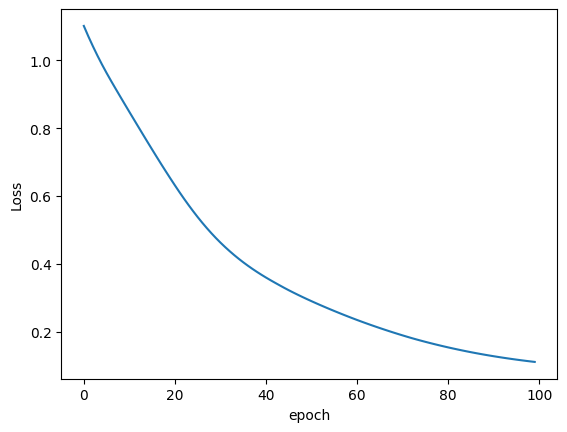

In [ ]:
plt.plot(range(epochs), train_losses)
plt.ylabel('Loss')
plt.xlabel('epoch');

## **Evaluation**

In [ ]:
with torch.no_grad():
    # Pass the test data through the model
    test_raw_predictions = model(X_test_t)
    print(test_raw_predictions.shape)
    print(test_raw_predictions)

    # Find the index of the highest score for each flower
    # dim=1 means we check across the 3 class columns for each row
    predicted_classes = torch.argmax(test_raw_predictions, dim=1)

    # Calculate Accuracy
    correct = (predicted_classes == y_test_t).sum().item()
    total = y_test_t.size(0)
    accuracy = (correct / total) * 100

print("=" * 40)
print(f"FINAL TEST ACCURACY: {accuracy:.2f}%")
print("=" * 40)

# Print a few examples to show the students
print("\nSample Predictions vs Actual:")
species_names = iris.target_names # ['setosa', 'versicolor', 'virginica']

for i in range(5):
    pred_idx = predicted_classes[i].item()
    actual_idx = y_test_t[i].item()

    pred_name = species_names[pred_idx]
    actual_name = species_names[actual_idx]

    print(f"Flower {i+1} -> Predicted: {pred_name:10} | Actual: {actual_name}")

torch.Size([45, 3])
tensor([[-2.2004,  3.2508,  0.5545],
        [ 2.9155, -2.9423, -3.9926],
        [-8.8450,  0.6442,  9.0169],
        [-2.2889,  2.4323,  0.8975],
        [-3.3855,  3.3262,  1.9293],
        [ 2.4501, -2.3282, -3.5225],
        [-0.6716,  2.2028, -0.8211],
        [-4.8087,  0.6539,  4.6202],
        [-4.8287,  2.9564,  2.9005],
        [-1.6406,  3.2791, -0.2667],
        [-3.4278,  1.0622,  3.0026],
        [ 2.2686, -1.9896, -3.4630],
        [ 2.7963, -2.7850, -3.8721],
        [ 2.3666, -2.1426, -3.5325],
        [ 3.1001, -3.1859, -4.1791],
        [-1.6042,  2.1190,  0.6779],
        [-5.2024,  0.2221,  5.1279],
        [-1.9224,  3.4468, -0.1917],
        [-1.8940,  2.7412,  0.2405],
        [-5.6054,  0.3340,  5.3003],
        [ 2.4905, -2.3814, -3.5632],
        [-3.0991,  1.4360,  2.2552],
        [ 2.5002, -2.3942, -3.5730],
        [-5.3747,  0.6088,  4.9653],
        [-3.8108,  1.3291,  4.4075],
        [-5.0624,  0.4641,  4.8380],
        [-6.1468, 

Here's what happens in `correct = (predicted_classes == y_test_t).sum().item()` :

- `(predicted_classes == y_test_t)` creates a boolean tensor where True indicates a correct prediction.

- `.sum()` calculates the total number of True values (correct predictions), resulting in a single-element tensor (e.g., tensor(45)).

- `.item()` is then called on this single-element tensor to convert it into a standard Python integer (45), which can then be used in the accuracy calculation.


## **Save the trained model to a file**
Right now <strong><tt>model</tt></strong> has been trained and validated. Let's save this to disk.<br>
The tools we'll use are <a href='https://pytorch.org/docs/stable/torch.html#torch.save'><strong><tt>torch.save()</tt></strong></a> and <a href='https://pytorch.org/docs/stable/torch.html#torch.load'><strong><tt>torch.load()</tt></strong></a><br>

There are two basic ways to save a model.<br>




### **Option 1: Saving and loading the `state_dict()` (recommended)**

In [ ]:
torch.save(model.state_dict(), 'IrisDatasetModelDict.pt')

new_model_dict = IrisClassifier()
new_model_dict.load_state_dict(torch.load('IrisDatasetModelDict.pt'))
new_model_dict.eval()

IrisClassifier(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (output_layer): Linear(in_features=8, out_features=3, bias=True)
  (act): ReLU()
)

**What it saves:** This method saves only the model's learned parameters (weights and biases) in an `OrderedDict` object. It does not save the model's architecture or class definition.

**When to use:**

- **Most common and recommended approach:** This is the standard practice for deployment, sharing trained models, or resuming training.

- **Flexibility:** It allows you to load the weights into a different model architecture, as long as the layers and their names match. This is useful for transfer learning or when you refactor your model code.

- **Smaller file size:** Since it only stores parameters, the saved file (.pt or .pth) is typically much smaller.

- **Security & Compatibility:** It avoids potential issues with class definitions changing or not being available, and is generally more robust against changes in PyTorch versions. It's also safer as it doesn't execute custom code during loading (as seen with the **weights_only=True** default).

**How it works:**

1. Define or instantiate your model class (**IrisClassifier()**).
2. Load the `state_dict` into this instantiated model.

### **Option 2: Saving and loading the entire model**

In [ ]:
torch.save(model, 'IrisDatasetModel.pt')

new_model = torch.load('IrisDatasetModel.pt', weights_only=False) # Loads the entire model directly
new_model.eval()

IrisClassifier(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (output_layer): Linear(in_features=8, out_features=3, bias=True)
  (act): ReLU()
)

When you use `torch.save(model, 'IrisDatasetModel.pt')`, you're saving the entire model, including its class definition (IrisClassifier) which was defined in your current script (the __main__ module). PyTorch's security mechanism, with `weights_only=True`, sees this custom class as an 'Unsupported global' and blocks its unpickling.<br>

**What it saves:** This method saves the entire model object, including its architecture, learned parameters, and even optimizer state if it was part of the object you saved. It essentially pickles the entire Python object.

**When to use:**

- **Local development and quick checkpoints:** It's convenient for saving and loading models within the same project or script where the model's class definition is guaranteed to be present and unchanged.

- **No need to re-instantiate:** You don't need to define the model class explicitly before loading; torch.load() directly returns the fully configured model object.

**How it works:**

1. Save the model instance directly (`torch.save(model, 'model.pt')`).
2. Load the model instance directly (`new_model = torch.load('model.pt')`).

**Important Considerations:**

- **Tight coupling:** This method creates a strong dependency on the exact class definition of your model. If you modify the IrisClassifier class (e.g., change layer names, add/remove layers), you might face issues loading older saved models.

- **Security risks:** Loading a pickled object from an untrusted source can execute malicious code. This is why PyTorch 2.6+ introduced weights_only=True as the default for torch.load, making state_dict loading safer by default.

- **Larger file size:** The saved file will contain more information than just the parameters.


For more information visit https://pytorch.org/tutorials/beginner/saving_loading_models.html

## **Apply the model to classify new, unseen data**

In [ ]:
mystery_iris = torch.tensor([5.6,3.7,2.2,0.5])

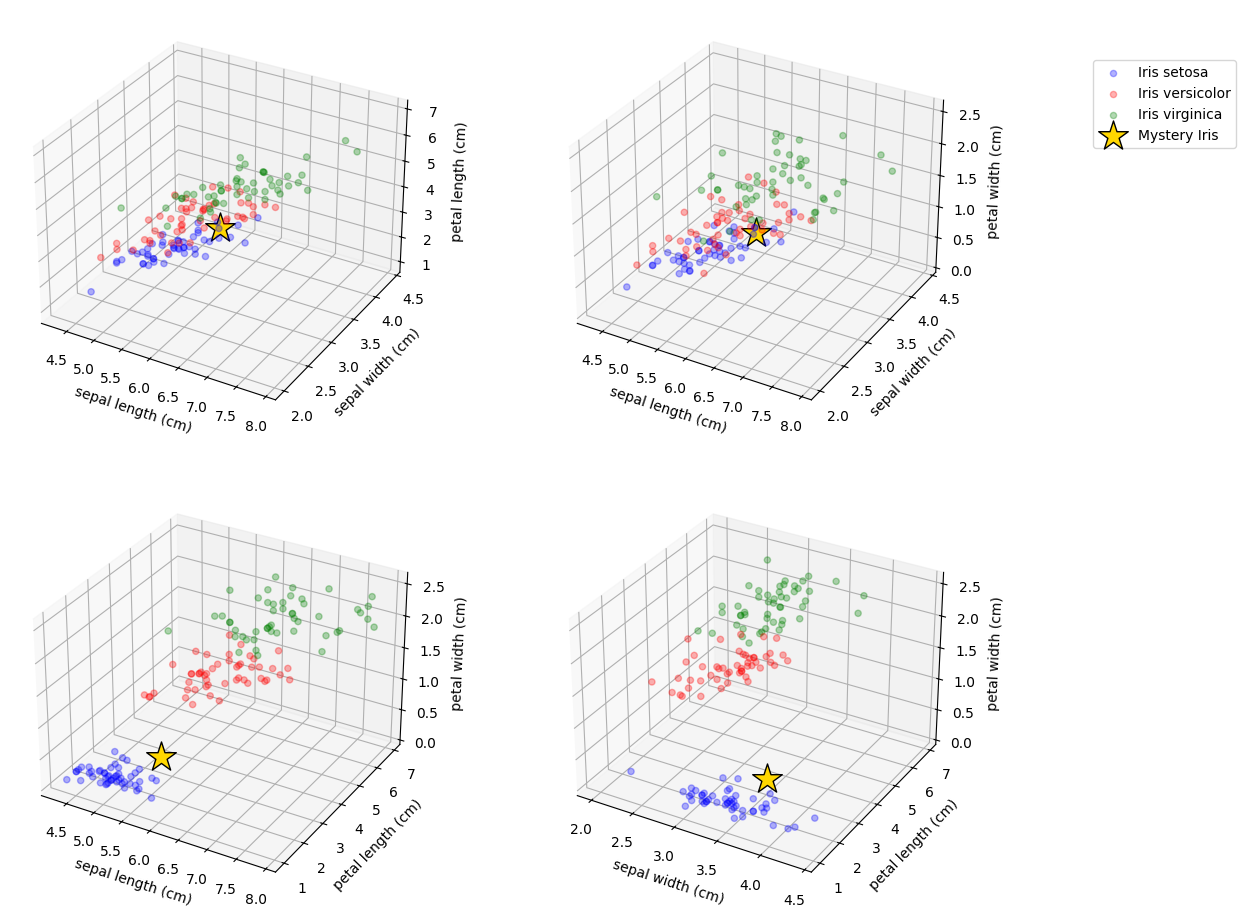

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_iris

# 1. Load the data
iris = load_iris()
X = iris.data
y = iris.target

# 2. Create the DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

# --- THE MYSTERY IRIS ---
mystery_iris = torch.tensor([5.6, 3.7, 2.2, 0.5])
# Convert tensor to a numpy array so we can easily index it [0, 1, 2, 3]
mystery_np = mystery_iris.numpy()

# 3. Set up the figure
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), subplot_kw={'projection': '3d'})
fig.tight_layout(pad=4.0)

plots = [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]
colors = ['b', 'r', 'g']
# Notice we added the Mystery Iris to the legend labels!
labels = ['Iris setosa', 'Iris versicolor', 'Iris virginica', 'Mystery Iris']

for i, ax in enumerate(axes.flat):
    # --- PLOT THE KNOWN FLOWERS ---
    for j in range(3):
        col_x = df.columns[plots[i][0]]
        col_y = df.columns[plots[i][1]]
        col_z = df.columns[plots[i][2]]

        x_vals = df[df['target'] == j][col_x]
        y_vals = df[df['target'] == j][col_y]
        z_vals = df[df['target'] == j][col_z]

        # Use alpha=0.3 to make the normal dots slightly transparent
        ax.scatter(x_vals, y_vals, z_vals, color=colors[j], alpha=0.3)

    # --- PLOT THE MYSTERY IRIS ---
    # Grab the specific 3 coordinates needed for this specific subplot
    myst_x = mystery_np[plots[i][0]]
    myst_y = mystery_np[plots[i][1]]
    myst_z = mystery_np[plots[i][2]]

    # Plot as a massive gold star.
    # zorder=10 forces the star to be drawn ON TOP of the other dots!
    ax.scatter(myst_x, myst_y, myst_z, color='gold', edgecolor='black', marker='*', s=500, zorder=10)

    # Set labels
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)
    ax.set_zlabel(col_z)

fig.legend(labels=labels, loc='center left', bbox_to_anchor=(1.0, 0.85))
plt.show()

In [ ]:
with torch.no_grad():
    # Scale the mystery_iris first
    mystery_iris_scaled = scaler.transform(mystery_iris.reshape(1, -1))
    mystery_iris_t = torch.tensor(mystery_iris_scaled, dtype=torch.float32)

    prediction = new_model(mystery_iris_t).argmax().item()
    predicted_species = species_names[prediction]
    print(f"Raw Model Output: {new_model(mystery_iris_t)}")
    print(f"Predicted Species: {predicted_species}")

Raw Model Output: tensor([[ 2.4754, -2.3616, -3.5481]])
Predicted Species: setosa


<br><br>

## **In class assignment**

Use pytorch and NN for "Palmer Penguins" dataset you worked on previously.